# 03 · Model Training & Evaluation
Trains a Logistic Regression baseline and an XGBoost champion model. 
Evaluates performance on the holdout test set (2024-2025) with a focus on 
**Recall**, because in early warning systems, missing a real drought (False Negative) 
is far more dangerous than a false alarm (False Positive).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

DATA_DIR = Path("../../data_pipeline/data/processed")
MODEL_DIR = Path("../models")

# Load artifacts from Notebook 02
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv")['target_risk']
X_test  = pd.read_csv(DATA_DIR / "X_test.csv")
y_test  = pd.read_csv(DATA_DIR / "y_test.csv")['target_risk']
scaler  = joblib.load(MODEL_DIR / "scaler.joblib")

# 1. Logistic Regression Baseline (Requires scaled data)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)
print("✅ Logistic Regression baseline trained.")

✅ Logistic Regression baseline trained.


In [2]:
# Calculate scale_pos_weight to handle class imbalance (approx 3:1 Safe:Risk)
# This tells XGBoost to penalize missing a drought heavier than a false alarm
scale_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_w,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

# XGBoost handles unscaled data beautifully
xgb_model.fit(X_train, y_train)
print("✅ XGBoost champion model trained.")

/home/mikel/.pyenv/versions/3.12.9/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [20:29:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost champion model trained.



--- Logistic Regression (Baseline) ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       823
           1       0.85      0.90      0.88        70

    accuracy                           0.98       893
   macro avg       0.92      0.94      0.93       893
weighted avg       0.98      0.98      0.98       893

ROC-AUC: 0.9953


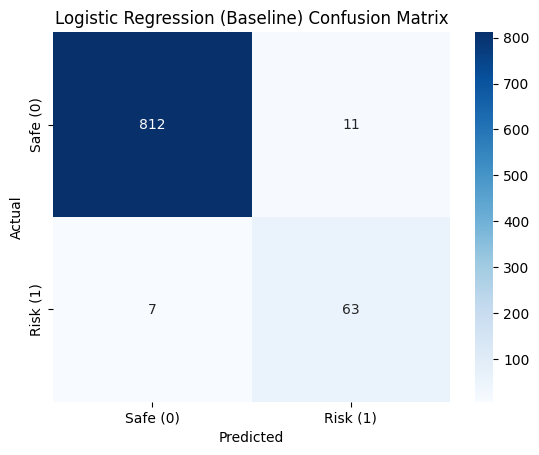


--- XGBoost (Champion) ---
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       823
           1       1.00      0.89      0.94        70

    accuracy                           0.99       893
   macro avg       1.00      0.94      0.97       893
weighted avg       0.99      0.99      0.99       893

ROC-AUC: 0.9986


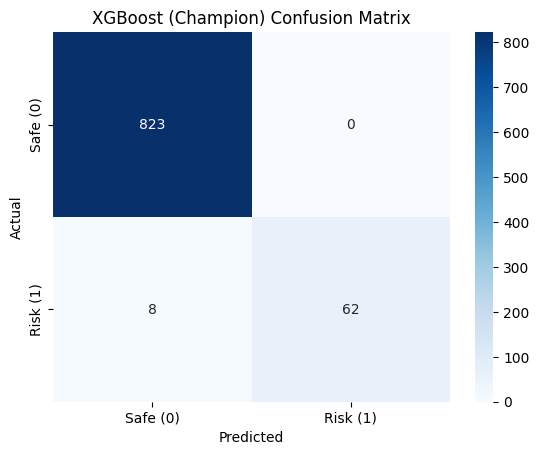

In [3]:
def evaluate_model(model, X, y, X_scaled=None, name="Model"):
    preds = model.predict(X_scaled if X_scaled is not None else X)
    probs = model.predict_proba(X_scaled if X_scaled is not None else X)[:, 1]
    
    print(f"\n--- {name} ---")
    print(classification_report(y, preds))
    print(f"ROC-AUC: {roc_auc_score(y, probs):.4f}")
    
    cm = confusion_matrix(y, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Safe (0)', 'Risk (1)'], 
                yticklabels=['Safe (0)', 'Risk (1)'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(lr_model, X_test, y_test, X_test_scaled, "Logistic Regression (Baseline)")
evaluate_model(xgb_model, X_test, y_test, name="XGBoost (Champion)")

/tmp/ipykernel_693643/2804310866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')


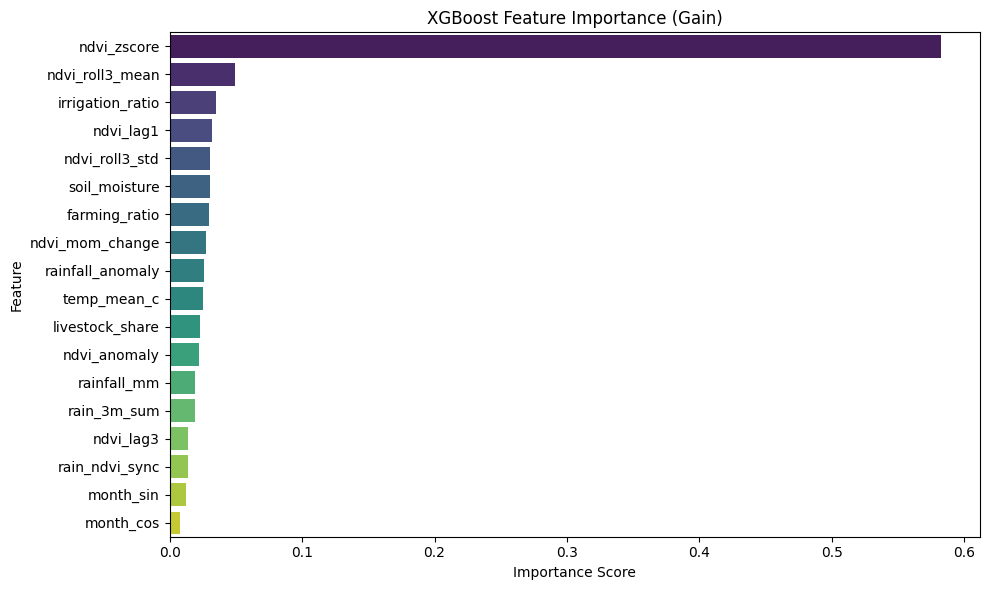

In [4]:
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='viridis')
plt.title('XGBoost Feature Importance (Gain)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [5]:
# Save the model artifact so the FastAPI backend can load it later
joblib.dump(xgb_model, MODEL_DIR / "xgboost_agrishield_v1.joblib")
print("💾 XGBoost model saved to ml-models/models/xgboost_agrishield_v1.joblib")

💾 XGBoost model saved to ml-models/models/xgboost_agrishield_v1.joblib
